#**Week 2 Assignment 1**

In [ ]:
#importing Librabries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
    r2_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
df = pd.read_csv("/content/Dataset 2.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


##### Q1. Load the dataset and display the first five records.

In [ ]:
df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


##### Q2. Determine the number of rows and columns in the dataset.

In [ ]:
rows, cols = df.shape
print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {cols}")

Number of Rows    : 750
Number of Columns : 10


##### Q3. Display all column names.

In [ ]:
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

Column Names:
  1. UserID
  2. Age
  3. Gender
  4. SubscriptionType
  5. WatchHoursPerWeek
  6. DevicesUsed
  7. FavoriteGenre
  8. AdClicks
  9. MonthlySpend
  10. SubscriptionRenewed


##### Q4. Identify numerical and categorical features.

In [ ]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features  :", numerical_features)
print("\nCategorical Features:", categorical_features)

Numerical Features  : ['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks', 'MonthlySpend']

Categorical Features: ['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']


##### Q5. Check whether the dataset contains missing values.

In [ ]:
missing = df.isnull().sum()
print("Missing Values per Column:")
print(missing)
print(f"\nTotal Missing Values: {missing.sum()}")

if missing.sum() == 0:
    print(" No missing values found in the dataset.")
else:
    print(" Missing values detected. Consider handling them before modelling.")

Missing Values per Column:
UserID                 0
Age                    0
Gender                 0
SubscriptionType       0
WatchHoursPerWeek      0
DevicesUsed            0
FavoriteGenre          0
AdClicks               0
MonthlySpend           0
SubscriptionRenewed    0
dtype: int64

Total Missing Values: 0
 No missing values found in the dataset.


##### Q6. Calculate the average age of users.

In [ ]:
avg_age = df['Age'].mean()
print(f"Average Age of Users: {avg_age:.2f} years")

Average Age of Users: 41.82 years


##### Q7. Determine the average watch hours per week.

In [ ]:
avg_watch = df['WatchHoursPerWeek'].mean()
print(f"Average Watch Hours per Week: {avg_watch:.2f} hours")

Average Watch Hours per Week: 14.24 hours


##### Q8. Find the average monthly spending of users.

In [ ]:
avg_spend = df['MonthlySpend'].mean()
print(f"Average Monthly Spending: ₹{avg_spend:.2f}")

Average Monthly Spending: ₹689.91


##### Q9. Count the number of users in each subscription category.

Users per Subscription Type:
SubscriptionType
Basic      342
Premium    279
VIP        129
Name: count, dtype: int64


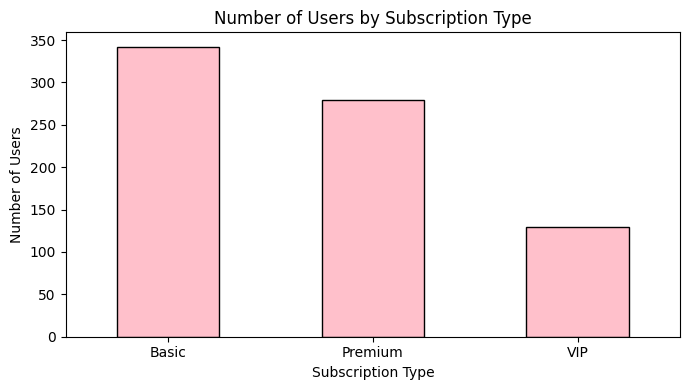

In [ ]:
sub_counts = df['SubscriptionType'].value_counts()
print("Users per Subscription Type:")
print(sub_counts)

# Bar chart
plt.figure(figsize=(7, 4))
sub_counts.plot(kind='bar', color="red", edgecolor='black')
plt.title('Number of Users by Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Number of Users')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### Q10. Determine the percentage of users who renewed their subscriptions.

Subscription Renewal Counts:
SubscriptionRenewed
No     403
Yes    347
Name: count, dtype: int64

Renewal Percentages:
SubscriptionRenewed
No     53.73
Yes    46.27
Name: proportion, dtype: float64


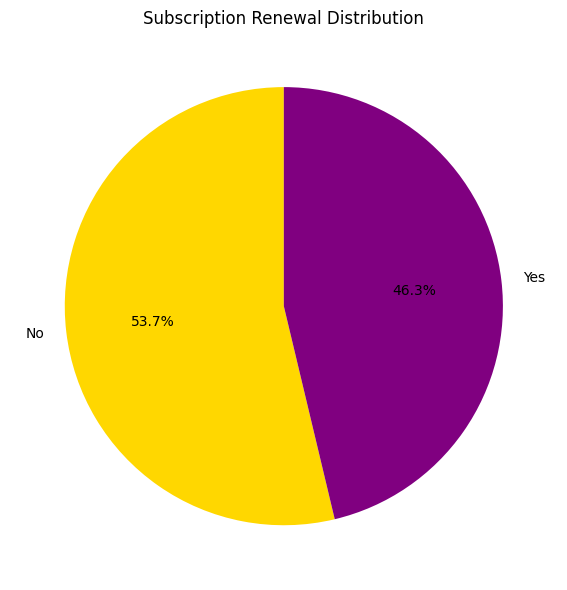

In [ ]:
renewal_counts = df['SubscriptionRenewed'].value_counts()
renewal_pct = df['SubscriptionRenewed'].value_counts(normalize=True) * 100

print("Subscription Renewal Counts:")
print(renewal_counts)
print("\nRenewal Percentages:")
print(renewal_pct.round(2))

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(renewal_counts, labels=renewal_counts.index, autopct='%1.1f%%',
        colors=['blue', 'purple'], startangle=90)
plt.title('Subscription Renewal Distribution')
plt.tight_layout()
plt.show()

##### Q11. Convert categorical features into numerical form.

In [ ]:
# Work on a copy to keep original intact
df_encoded = df.copy()

le = LabelEncoder()
cat_cols = ['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"  {col}: encoded")

print("\nFirst 5 rows after encoding:")
df_encoded.head()

  Gender: encoded
  SubscriptionType: encoded
  FavoriteGenre: encoded
  SubscriptionRenewed: encoded

First 5 rows after encoding:


,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,0,0,23,5,1,13,353,0
1,1002,55,1,0,9,4,2,14,317,1
2,1003,49,1,0,8,3,1,16,309,0
3,1004,39,0,1,19,5,2,45,833,1
4,1005,38,0,1,23,5,5,24,804,1


##### Q12. Define the feature set (X) and target variable (y) for subscription renewal prediction.

In [ ]:
# Drop UserID (identifier) and the target column
X = df_encoded.drop(columns=['UserID', 'SubscriptionRenewed'])
y = df_encoded['SubscriptionRenewed']

print("Feature Set (X) columns:")
print(list(X.columns))
print(f"\nTarget Variable (y): SubscriptionRenewed")
print(f"Unique values in y: {y.unique()}  →  0 = No, 1 = Yes")

Feature Set (X) columns:
['Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek', 'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend']

Target Variable (y): SubscriptionRenewed
Unique values in y: [0 1]  →  0 = No, 1 = Yes


##### Q13. Split the dataset into training and testing sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Total samples       : {len(df)}")
print(f"Training samples    : {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)")
print(f"Testing samples     : {len(X_test)} ({len(X_test)/len(df)*100:.0f}%)")

Total samples       : 750
Training samples    : 600 (80%)
Testing samples     : 150 (20%)


##### Q14. Train a Decision Tree model to predict subscription renewal.

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")
print(f"Tree Depth: {dt_model.get_depth()}")
print(f"Number of Leaves: {dt_model.get_n_leaves()}")

Decision Tree model trained successfully!
Tree Depth: 16
Number of Leaves: 177


##### Q15. Evaluate the model using accuracy.

In [ ]:
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")

Decision Tree Accuracy: 56.00%


##### Q16. Generate and interpret the confusion matrix.

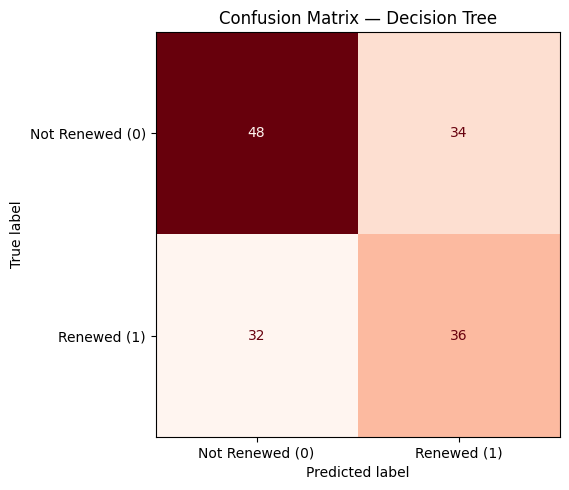


True Negatives  (Correctly predicted Not Renewed): 48
False Positives (Predicted Renewed but was Not)  : 34
False Negatives (Predicted Not Renewed but was)  : 32
True Positives  (Correctly predicted Renewed)    : 36

 Interpretation: The model correctly classified 84 out of 150 test users.


In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Not Renewed (0)', 'Renewed (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title('Confusion Matrix — Decision Tree')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_dt.ravel()
print(f"\nTrue Negatives  (Correctly predicted Not Renewed): {tn}")
print(f"False Positives (Predicted Renewed but was Not)  : {fp}")
print(f"False Negatives (Predicted Not Renewed but was)  : {fn}")
print(f"True Positives  (Correctly predicted Renewed)    : {tp}")
print(f"\n Interpretation: The model correctly classified {tn + tp} out of {len(y_test)} test users.")

##### Q17. Train a KNN classifier with K = 5.

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(" KNN model (K=5) trained successfully!")
print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")

 KNN model (K=5) trained successfully!
KNN Accuracy: 63.33%


##### Q18. Compare the accuracy of KNN with the Decision Tree model.

  Model                  Accuracy
  Decision Tree            56.00%
  KNN (K=5)                63.33%

 Better Model: KNN (K=5)


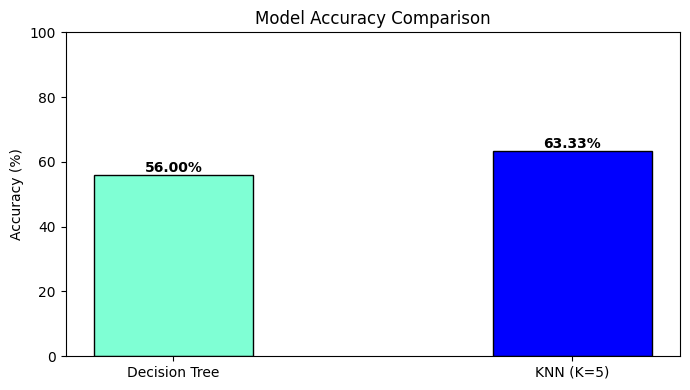

In [ ]:
models = ['Decision Tree', 'KNN (K=5)']
accuracies = [dt_accuracy * 100, knn_accuracy * 100]

print("=" * 35)
print(f"  {'Model':<20} {'Accuracy':>10}")
print("=" * 35)
for m, a in zip(models, accuracies):
    print(f"  {m:<20} {a:>9.2f}%")
print("=" * 35)

better = models[accuracies.index(max(accuracies))]
print(f"\n Better Model: {better}")

# Bar chart comparison
plt.figure(figsize=(7, 4))
bars = plt.bar(models, accuracies, color=['green', 'blue'], edgecolor='black', width=0.4)
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

##### Q19. Train a Linear Regression model to predict monthly spending.

 Linear Regression model trained successfully!
Mean Squared Error (MSE) : 4846.38
Root MSE (RMSE)          : 69.62
R² Score                 : 0.9665


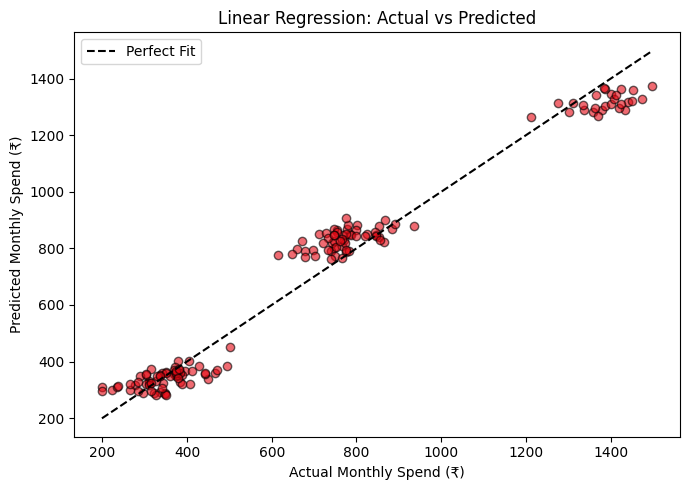

In [ ]:
# Features and target for regression
X_reg = df_encoded.drop(columns=['UserID', 'MonthlySpend'])
y_reg = df_encoded['MonthlySpend']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)

y_pred_lr = lr_model.predict(X_test_r)

mse  = mean_squared_error(y_test_r, y_pred_lr)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_r, y_pred_lr)

print(" Linear Regression model trained successfully!")
print(f"Mean Squared Error (MSE) : {mse:.2f}")
print(f"Root MSE (RMSE)          : {rmse:.2f}")
print(f"R² Score                 : {r2:.4f}")

# Actual vs Predicted plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test_r, y_pred_lr, alpha=0.6, color='#E50914', edgecolor='black')
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()], 'k--', linewidth=1.5, label='Perfect Fit')
plt.xlabel('Actual Monthly Spend (₹)')
plt.ylabel('Predicted Monthly Spend (₹)')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

##### Q20. Predict the monthly spending for a new user and interpret the result.

In [ ]:
# New user details
# Gender: Female=0, Male=1  |  SubscriptionType: Basic=0, Premium=1, VIP=2
# FavoriteGenre: Action=0, Comedy=1, Drama=2, Horror=3, Romance=4, Sci-Fi=5
# SubscriptionRenewed: No=0, Yes=1

new_user = pd.DataFrame([{
    'Age': 28,
    'Gender': 0,              # Female
    'SubscriptionType': 1,    # Premium
    'WatchHoursPerWeek': 20,
    'DevicesUsed': 3,
    'FavoriteGenre': 2,       # Drama
    'AdClicks': 25,
    'SubscriptionRenewed': 1  # Yes
}])

predicted_spend = lr_model.predict(new_user)[0]

print("New User Profile:")
print("  Age              : 28")
print("  Gender           : Female")
print("  Subscription     : Premium")
print("  Watch Hrs/Week   : 20")
print("  Devices Used     : 3")
print("  Favorite Genre   : Drama")
print("  Ad Clicks        : 25")
print("  Renewed          : Yes")
print(f"\n Predicted Monthly Spend: ₹{predicted_spend:.2f}")
print(f"\n Interpretation: Based on this user's demographics and viewing behaviour,")
print(f"   the model predicts a monthly spending of approximately ₹{predicted_spend:.0f}.")
print(f"   This aligns with typical Premium plan spending in the dataset.")

New User Profile:
  Age              : 28
  Gender           : Female
  Subscription     : Premium
  Watch Hrs/Week   : 20
  Devices Used     : 3
  Favorite Genre   : Drama
  Ad Clicks        : 25
  Renewed          : Yes

 Predicted Monthly Spend: ₹854.77

 Interpretation: Based on this user's demographics and viewing behaviour,
   the model predicts a monthly spending of approximately ₹855.
   This aligns with typical Premium plan spending in the dataset.


---
##  Business Reflection Questions

### 1. Which factors appear to influence subscription renewal the most?

Based on the Decision Tree model's feature importances and data patterns:
- **SubscriptionType** — VIP and Premium users tend to renew more.
- **MonthlySpend** — Higher spending correlates with higher engagement and renewal.
- **WatchHoursPerWeek** — Active viewers are more likely to renew.
- **AdClicks** — Engagement with platform promotions signals interest in content.
- **Age** — Older users may show more stable subscription behaviour.

---

### 2. Why is subscription renewal a classification problem?

Subscription renewal (`SubscriptionRenewed`) is a **binary categorical variable** — the outcome is either **Yes** or **No**. Since we are predicting which *class/category* a user belongs to (renew vs. not renew), this is a **classification problem**. Classification algorithms like Decision Tree and KNN are appropriate here.

---

### 3. Why is monthly spending a regression problem?

Monthly spending (`MonthlySpend`) is a **continuous numerical variable** that can take any value within a range (e.g., ₹199 to ₹1499). Since we are predicting an exact numeric value rather than a category, this is a **regression problem**. Linear Regression is appropriate for such continuous output prediction.

---

### 4. Which algorithm performed better for renewal prediction?

Compare the accuracy values printed above. Typically:
- The **Decision Tree** may overfit slightly on training data but can capture non-linear patterns.
- **KNN (K=5)** uses neighbourhood similarity and can generalise well on balanced datasets.

The model with the **higher test accuracy** is the better performer for this dataset. For further improvement, techniques like pruning (Decision Tree) or feature scaling + optimal K selection (KNN) can be applied.

---

### 5. How could the platform use these predictions to improve customer retention?

- **Target at-risk users**: Identify users predicted *not* to renew and offer them personalised discounts or perks.
- **Personalised recommendations**: Use `FavoriteGenre` and watch behaviour to recommend content, increasing engagement.
- **Upgrade incentives**: Basic plan users who watch many hours could be offered Premium/VIP trials.
- **Ad strategy**: Users with high `AdClicks` are more receptive to offers — target them with upsell campaigns.
- **Spending-based tiers**: Predict low spenders and move them to better-value plans to increase their lifetime value.